<a href="https://colab.research.google.com/github/Bharathp953/Azure/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mixed precision enabled: <DTypePolicy "mixed_float16">
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Tasks:   0%|          | 0/10 [00:00<?, ?it/s]

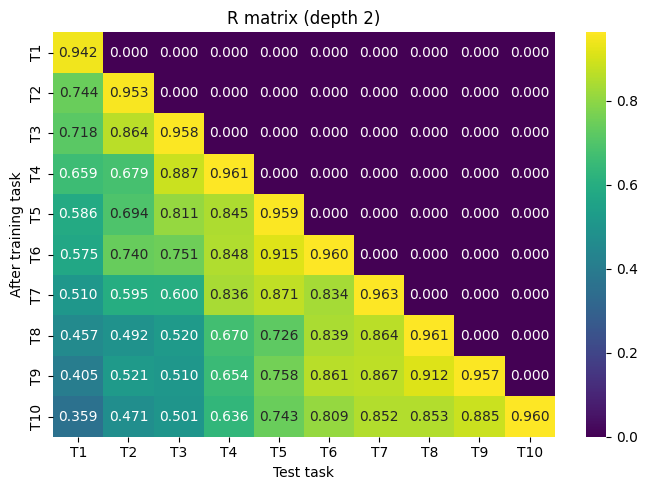

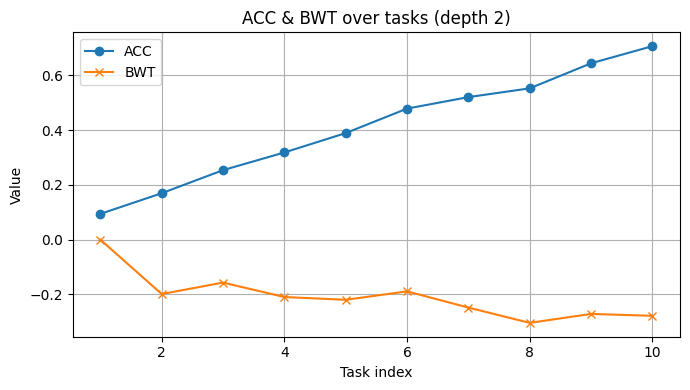

Depth 2 done | Graphs saved: results_fast/R_depth2.png, results_fast/ACC_BWT_depth2.png | Time: 2.72 min


In [1]:
# permuted_mnist_fast_graphs.py
import os, time, numpy as np, tensorflow as tf, matplotlib.pyplot as plt, seaborn as sns
from tensorflow.keras.datasets import mnist
from tqdm.notebook import tqdm
from IPython.display import display

# -----------------------------
# Config / Hyperparameters
# -----------------------------
RND_SEED = 207
tf.random.set_seed(RND_SEED)
np.random.seed(RND_SEED)

NUM_TASKS = 10
NUM_EPOCHS = 5
MINIBATCH_SIZE = 256
LEARNING_RATE = 1e-3
HIDDEN_UNITS = 256
MODEL_DEPTHS = [2]  # Single depth for speed
TRAIN_SUBSET_SIZE = 20000
USE_MIXED_PRECISION = True
AUTOTUNE = tf.data.AUTOTUNE

# -----------------------------
# Mixed precision
# -----------------------------
if USE_MIXED_PRECISION:
    from tensorflow.keras import mixed_precision
    policy = mixed_precision.Policy("mixed_float16")
    mixed_precision.set_global_policy(policy)
    print("Mixed precision enabled:", mixed_precision.global_policy())

# -----------------------------
# Utilities
# -----------------------------
def make_permutations(num_tasks, dim, seed=RND_SEED):
    rng = np.random.RandomState(seed)
    return [rng.permutation(dim) for _ in range(num_tasks)]

def apply_permutation_np(X, perm):
    return X[:, perm]

def to_one_hot_np(y, n_classes=10):
    return np.eye(n_classes, dtype=np.float32)[y]

# -----------------------------
# Load & preprocess MNIST
# -----------------------------
(x_train_all, y_train_all), (x_test_all, y_test_all) = mnist.load_data()
x_train_all = (x_train_all.astype(np.float32)/255.0).reshape(-1,28*28)
x_test_all = (x_test_all.astype(np.float32)/255.0).reshape(-1,28*28)
y_train_all = y_train_all.astype(np.int32)
y_test_all = y_test_all.astype(np.int32)

x_train_all = x_train_all[:TRAIN_SUBSET_SIZE]
y_train_all = y_train_all[:TRAIN_SUBSET_SIZE]

# -----------------------------
# Manual MLP
# -----------------------------
class ManualMLP:
    def __init__(self, input_dim, hidden_units, n_hidden_layers, n_classes):
        self.params = []
        init = tf.initializers.RandomNormal(0.0, 0.01, seed=RND_SEED)
        in_dim = input_dim
        for _ in range(n_hidden_layers):
            W = tf.Variable(init([in_dim, hidden_units]), dtype=tf.float32)
            b = tf.Variable(tf.zeros([hidden_units]), dtype=tf.float32)
            self.params.append((W,b))
            in_dim = hidden_units
        W_out = tf.Variable(init([in_dim, n_classes]), dtype=tf.float32)
        b_out = tf.Variable(tf.zeros([n_classes]), dtype=tf.float32)
        self.params.append((W_out,b_out))
    def forward(self,x):
        h = x
        for W,b in self.params[:-1]:
            h = tf.nn.relu(tf.matmul(h,W)+b)
        W,b = self.params[-1]
        logits = tf.matmul(h,W)+b
        return tf.cast(logits, tf.float32)
    def variables(self):
        return [v for pair in self.params for v in pair]

# -----------------------------
# Training step
# -----------------------------
def train_step(model, optimizer, x_batch, y_batch_onehot):
    with tf.GradientTape() as tape:
        logits = model.forward(x_batch)
        loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(labels=y_batch_onehot, logits=logits))
    grads = tape.gradient(loss, model.variables())
    optimizer.apply_gradients(zip(grads, model.variables()))
    return loss

# -----------------------------
# Dataset
# -----------------------------
def make_dataset(X_np, y_np_onehot=None, batch_size=MINIBATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X_np, y_np_onehot)) if y_np_onehot is not None else tf.data.Dataset.from_tensor_slices(X_np)
    if shuffle: ds = ds.shuffle(10000, seed=RND_SEED)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

# -----------------------------
# Accuracy evaluation
# -----------------------------
def eval_accuracy(model, X_np, y_np):
    ds = tf.data.Dataset.from_tensor_slices((X_np, y_np)).batch(1024)
    correct,total = 0,0
    for xb,yb in ds:
        logits = model.forward(tf.cast(xb, tf.float32))
        preds = tf.argmax(logits,axis=1,output_type=tf.int32)
        correct += np.sum(preds.numpy()==yb.numpy())
        total += len(preds)
    return correct/total

# -----------------------------
# Run one depth
# -----------------------------
def run_permuted_mnist_for_depth(depth):
    input_dim, n_classes = 28*28, 10
    perms = make_permutations(NUM_TASKS,input_dim,RND_SEED+123)

    tasks_X_train, tasks_y_train, tasks_X_test, tasks_y_test = [],[],[],[]
    for t in range(NUM_TASKS):
        p = perms[t]
        tasks_X_train.append(apply_permutation_np(x_train_all,p))
        tasks_X_test.append(apply_permutation_np(x_test_all,p))
        tasks_y_train.append(y_train_all)
        tasks_y_test.append(y_test_all)

    model = ManualMLP(input_dim,HIDDEN_UNITS,depth,n_classes)
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

    task_datasets = [make_dataset(tasks_X_train[t],to_one_hot_np(tasks_y_train[t])) for t in range(NUM_TASKS)]
    R = np.zeros((NUM_TASKS,NUM_TASKS),dtype=np.float32)
    ACC_over_tasks, BWT_over_tasks = [],[]

    for task_idx in tqdm(range(NUM_TASKS),desc="Tasks"):
        ds = task_datasets[task_idx]
        for _ in range(NUM_EPOCHS):
            for xb,yb in ds:
                train_step(model,optimizer,tf.cast(xb,tf.float32),yb)

        # Evaluate after task
        for prev in range(task_idx+1):
            acc_prev = eval_accuracy(model,tasks_X_test[prev],tasks_y_test[prev])
            R[task_idx,prev] = acc_prev

        ACC = float(R[task_idx,:].mean())
        BWT = float(np.sum([R[task_idx,i]-R[i,i] for i in range(task_idx)])/max(1,task_idx))
        ACC_over_tasks.append(ACC)
        BWT_over_tasks.append(BWT)

    return model,R,ACC_over_tasks,BWT_over_tasks

# -----------------------------
# Main runner
# -----------------------------
def run_all():
    os.makedirs("results_fast",exist_ok=True)
    for depth in MODEL_DEPTHS:
        t0=time.time()
        model,R,ACC_over,BWT_over = run_permuted_mnist_for_depth(depth)
        dur=time.time()-t0

        # Heatmap
        plt.figure(figsize=(7,5))
        sns.heatmap(R,annot=True,fmt=".3f",cmap="viridis",
                    xticklabels=[f"T{i+1}" for i in range(R.shape[1])],
                    yticklabels=[f"T{i+1}" for i in range(R.shape[0])])
        plt.title(f"R matrix (depth {depth})")
        plt.xlabel("Test task")
        plt.ylabel("After training task")
        fname=os.path.join("results_fast",f"R_depth{depth}.png")
        plt.tight_layout(); plt.savefig(fname); display(plt.gcf()); plt.close()

        # ACC & BWT plots
        plt.figure(figsize=(7,4))
        plt.plot(range(1,NUM_TASKS+1),ACC_over,marker='o',label='ACC')
        plt.plot(range(1,NUM_TASKS+1),BWT_over,marker='x',label='BWT')
        plt.xlabel("Task index"); plt.ylabel("Value")
        plt.title(f"ACC & BWT over tasks (depth {depth})")
        plt.grid(True); plt.legend()
        fname2=os.path.join("results_fast",f"ACC_BWT_depth{depth}.png")
        plt.tight_layout(); plt.savefig(fname2); display(plt.gcf()); plt.close()

        print(f"Depth {depth} done | Graphs saved: {fname}, {fname2} | Time: {dur/60:.2f} min")

if __name__=="__main__":
    run_all()
